# Niveau 1 - Tâche 2 : Régression Linéaire

**Dataset choisi : House Prediction Data Set (Boston Housing)**

Ce dataset est parfaitement adapté : il contient une cible continue (le prix médian des maisons, `MEDV`) et 13 variables explicatives numériques (criminalité, nombre de pièces, distance aux emplois, etc.).

**Objectifs couverts :**
1. Chargement et prétraitement du dataset
2. Entraînement d'un modèle de régression linéaire avec scikit-learn
3. Interprétation des coefficients du modèle
4. Évaluation avec R² et MSE

**Outils :** Python, pandas, scikit-learn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
           'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

df = pd.read_csv('data/house_boston.csv', sep=r'\s+', header=None, names=columns)
print("Shape:", df.shape)
df.head()


Shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## 1. Description des variables

- `CRIM` : taux de criminalité par ville
- `RM` : nombre moyen de pièces par logement
- `LSTAT` : % de population de statut socio-économique bas
- `PTRATIO` : ratio élèves/enseignant
- `MEDV` : **cible** — valeur médiane des maisons (en milliers de $)


In [2]:
print(df.isna().sum().sum(), "valeurs manquantes")
df.describe().T


0 valeurs manquantes


,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


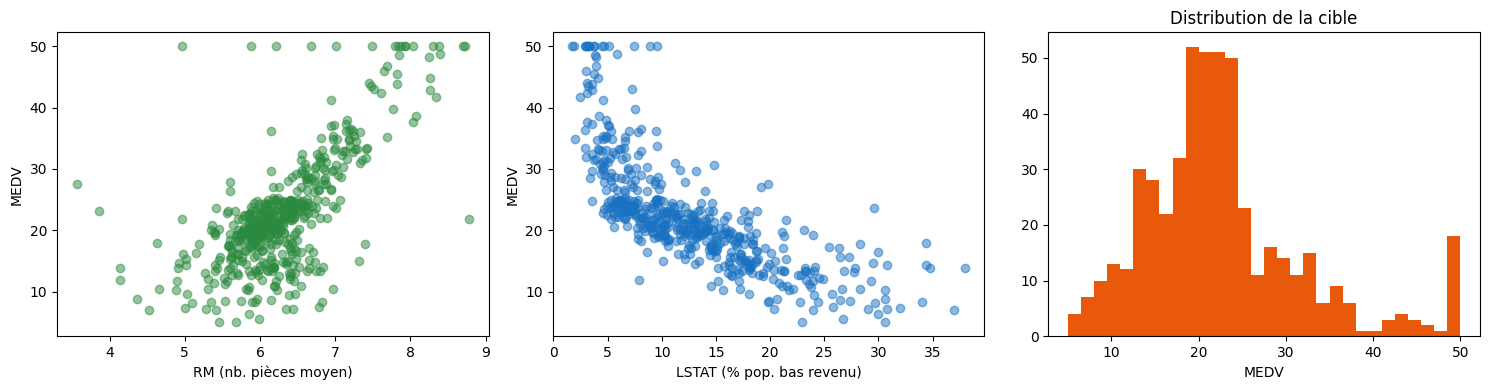

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(df['RM'], df['MEDV'], alpha=0.5, color='#2b8a3e')
axes[0].set_xlabel('RM (nb. pièces moyen)'); axes[0].set_ylabel('MEDV')
axes[1].scatter(df['LSTAT'], df['MEDV'], alpha=0.5, color='#1971c2')
axes[1].set_xlabel('LSTAT (% pop. bas revenu)'); axes[1].set_ylabel('MEDV')
axes[2].hist(df['MEDV'], bins=30, color='#e8590c')
axes[2].set_xlabel('MEDV'); axes[2].set_title('Distribution de la cible')
plt.tight_layout()
plt.show()


## 2. Prétraitement et split train/test

In [4]:
X = df.drop(columns=['MEDV'])
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train:", X_train_scaled.shape, " Test:", X_test_scaled.shape)


Train: (404, 13)  Test: (102, 13)


## 3. Entraînement du modèle de régression linéaire

In [5]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print("Modèle entraîné.")


Modèle entraîné.


## 4. Interprétation des coefficients

Comme les variables ont été standardisées, les coefficients sont directement comparables : ils indiquent l'effet d'un changement d'un écart-type de chaque variable sur le prix (en milliers de $).

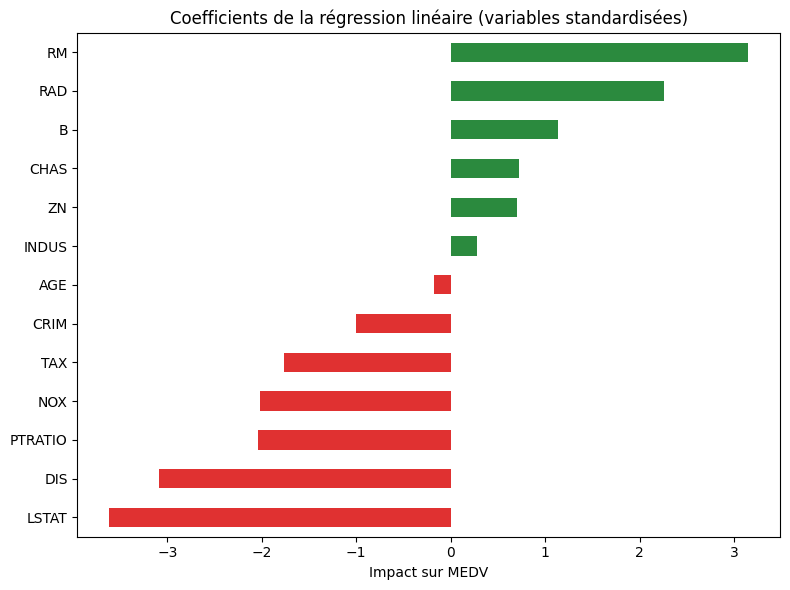

Intercept: 22.797


RM         3.145240
RAD        2.251407
B          1.129568
CHAS       0.718738
ZN         0.696269
INDUS      0.278065
AGE       -0.176048
CRIM      -1.002135
TAX       -1.767014
NOX       -2.022319
PTRATIO   -2.037752
DIS       -3.081908
LSTAT     -3.611658
dtype: float64

In [6]:
coefs = pd.Series(model.coef_, index=X.columns).sort_values()
plt.figure(figsize=(8, 6))
coefs.plot(kind='barh', color=['#e03131' if c < 0 else '#2b8a3e' for c in coefs])
plt.title("Coefficients de la régression linéaire (variables standardisées)")
plt.xlabel("Impact sur MEDV")
plt.tight_layout()
plt.show()

print(f"Intercept: {model.intercept_:.3f}")
coefs.sort_values(ascending=False)


## 5. Évaluation du modèle

MSE  : 24.291
RMSE : 4.929
R²   : 0.669


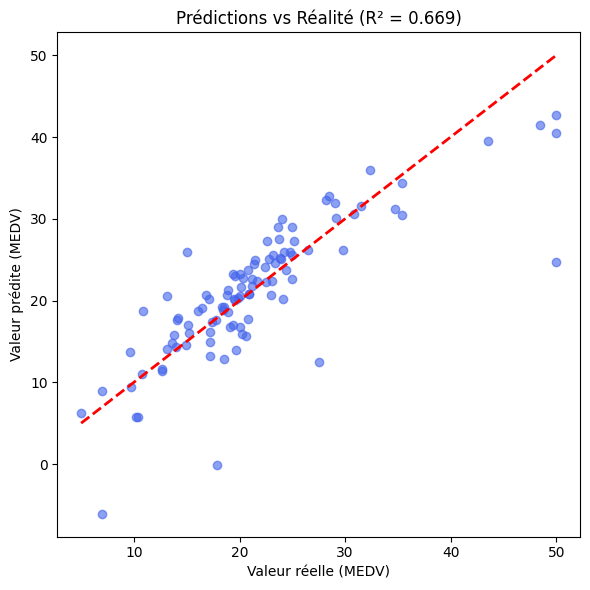

In [7]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='#4263eb')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Valeur réelle (MEDV)")
plt.ylabel("Valeur prédite (MEDV)")
plt.title(f"Prédictions vs Réalité (R² = {r2:.3f})")
plt.tight_layout()
plt.show()


## Conclusion

Le modèle de régression linéaire explique une part significative de la variance du prix des logements (R² reporté ci-dessus).
Les variables les plus influentes sont typiquement `RM` (nombre de pièces, effet positif) et `LSTAT` (% population à faible revenu, effet négatif), ce qui est cohérent avec l'intuition économique.
